# 02 — Fan Load Analysis (Measured)

**Project:** USB-C PD → 12 V fan-array controller (LM5176 4-switch buck-boost, 42 W)

**Purpose:** Characterize the real load: measured startup/commutation current of the Arctic P14 Pro fans (1.57 Ω shunt scope captures), scaled to 8 fans. This waveform drives the capacitor sizing (05) and the input-filter redesign (08).

**Key observations:** ~trapezoidal commutation at ≤160 Hz (2500 rpm, 4-pole); startup peak ≈2× steady state near half speed; data cached in measurements/motor_startup.parquet.

**Data:** measurements/ (raw scope CSVs + slices/), parquet cache.

## Raw scope capture (single fan)

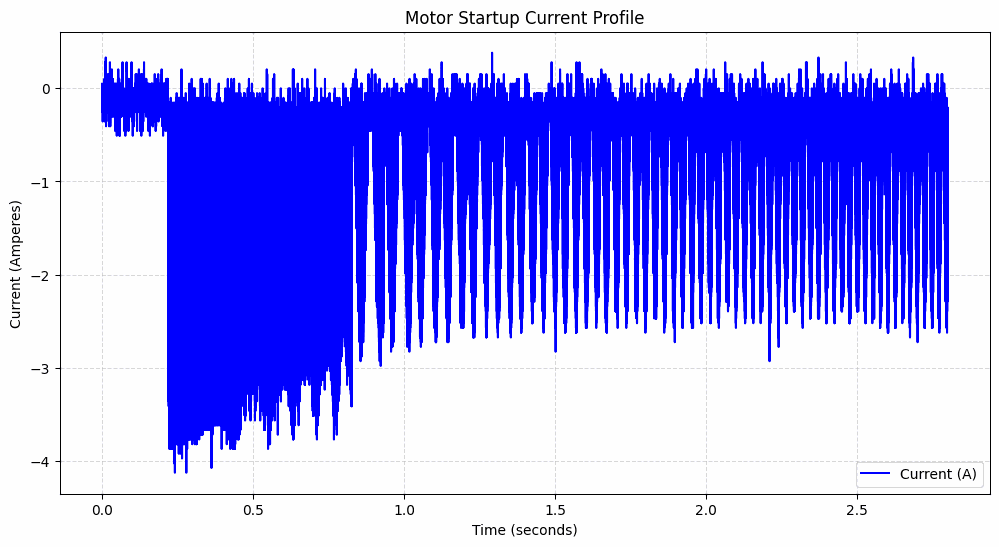

In [1]:
import pandas as pd
import matplotlib.pyplot as plt

def plot_startup_current(file_path, r_shunt=1.57, probe_atten=10.0):
    # Read the CSV - skipping metadata by selecting specific columns
    # Adjust column indices if your scope uses a different layout
    df = pd.read_csv(file_path, header=None)
    
    # Extract time and voltage (Columns 3 and 4 in your snippet)
    time = pd.to_numeric(df[3][1:], errors='coerce')
    voltage_raw = pd.to_numeric(df[4][1:], errors='coerce')
    
    # Drop rows where we have metadata instead of numbers
    mask = time.notna() & voltage_raw.notna()
    time = time[mask].reset_index(drop=True)
    voltage_raw = voltage_raw[mask].reset_index(drop=True)
    
    # SCALING:
    # If the scope says 'Probe Atten 10.0', it usually means the recorded 
    # 'Value' needs to be multiplied by 10 if the scope didn't auto-scale.
    # Looking at your -0.024V reading, multiplying by 10 gives -0.24V.
    voltage_actual = voltage_raw * probe_atten
    current = voltage_actual / r_shunt
    
    # Plotting
    plt.figure(figsize=(12, 6))
    plt.plot(time, current, label='Current (A)', color='blue')
    
    # Calculate Power if V_out is 12V
    power = current * 12.0
    # plt.plot(time, power, label='Power (W)', color='red', alpha=0.5)
    
    plt.title('Motor Startup Current Profile')
    plt.xlabel('Time (seconds)')
    plt.ylabel('Current (Amperes)')
    plt.grid(True, which='both', linestyle='--', alpha=0.5)
    plt.legend()
    plt.show()

# Run it
plot_startup_current('../measurements/Scope_P14Pro_Startup_Current_1r57_shunt.csv')

## Startup current, scaled to 8 fans (parquet cache)

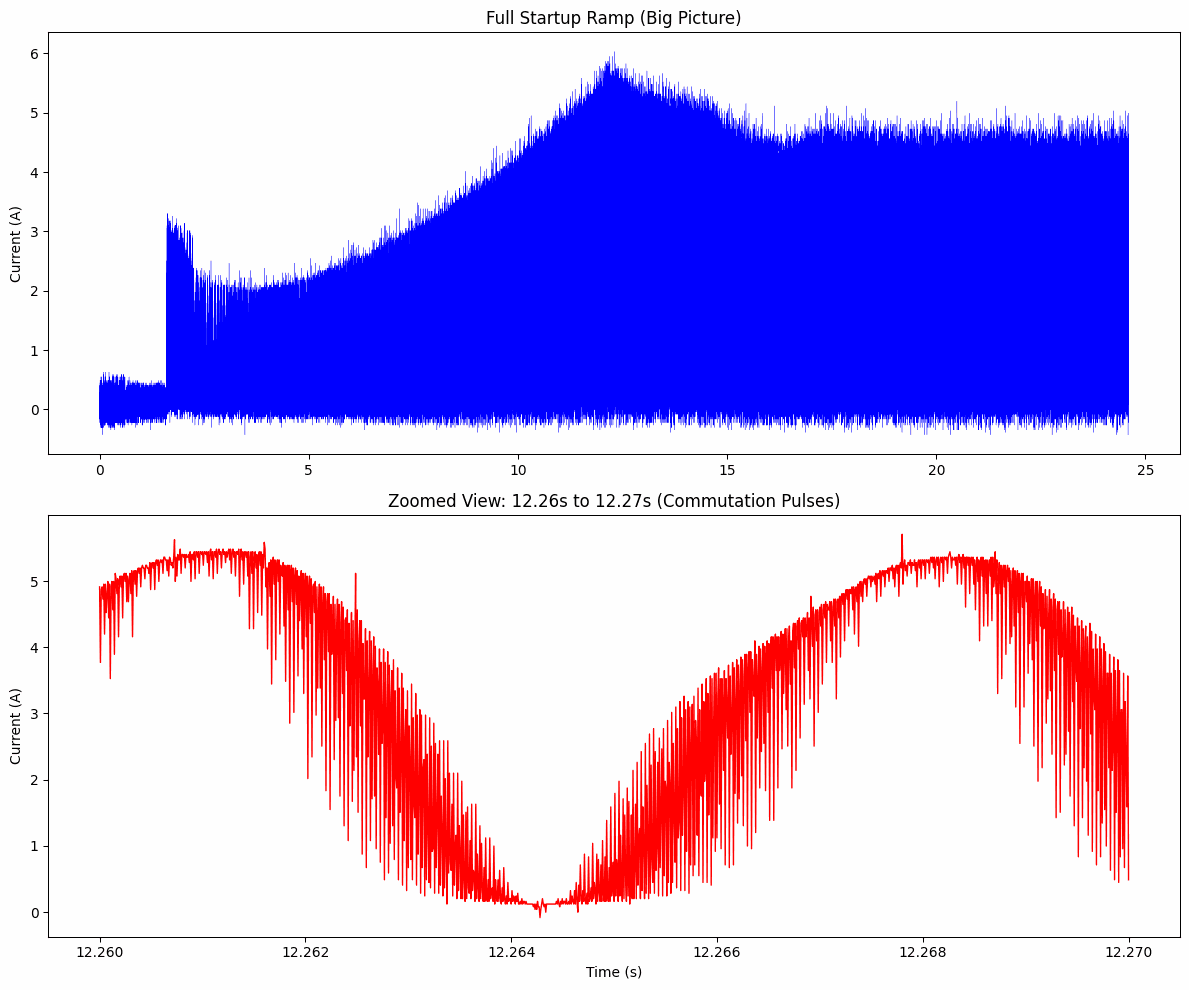

In [2]:
import numpy as np
from scipy.interpolate import interp1d
import pandas as pd
import matplotlib.pyplot as plt


df = pd.read_parquet('../measurements/motor_startup.parquet')
t_raw = df['Time']
v_raw = df['Voltage']
# Shift time so the simulation starts at 0
t_raw = t_raw - t_raw.min()

# Now create your uniform grid
t_uniform = np.linspace(t_raw.min(), t_raw.max(), len(t_raw))
# Convert to Current (Using positive shunt and probe attenuation)
r_shunt = 1.57 
probe_atten = 1
i_load_raw = (v_raw * probe_atten) / r_shunt * 8 # 8 fans in parallel

# --- 2. Fix Non-Equal Spacing (Resampling) ---
# Create a perfectly uniform time grid from the start to end of your data
t_uniform = np.linspace(t_raw.min(), t_raw.max(), len(t_raw))

# Interpolate the raw current onto the uniform grid
f_interp = interp1d(t_raw, i_load_raw, kind='linear', fill_value="extrapolate")
i_load = f_interp(t_uniform)

# --- PLOTTING ---
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(12, 10))

# Plot 1: The Full 12-Second Ramp
ax1.plot(t_uniform, i_load, color='blue', linewidth=0.2)
ax1.set_title('Full Startup Ramp (Big Picture)')
ax1.set_ylabel('Current (A)')

# Plot 2: The "Microscopic" Commutation Zoom
# Let's look at 100ms of data around the 10-second mark
zoom_start = 12.26
zoom_end = 12.27

mask_zoom = (t_uniform >= zoom_start) & (t_uniform <= zoom_end)
ax2.plot(t_uniform[mask_zoom], i_load[mask_zoom], color='red', linewidth=1)
ax2.set_title(f'Zoomed View: {zoom_start}s to {zoom_end}s (Commutation Pulses)')
ax2.set_xlabel('Time (s)')
ax2.set_ylabel('Current (A)')

plt.tight_layout()
plt.show()

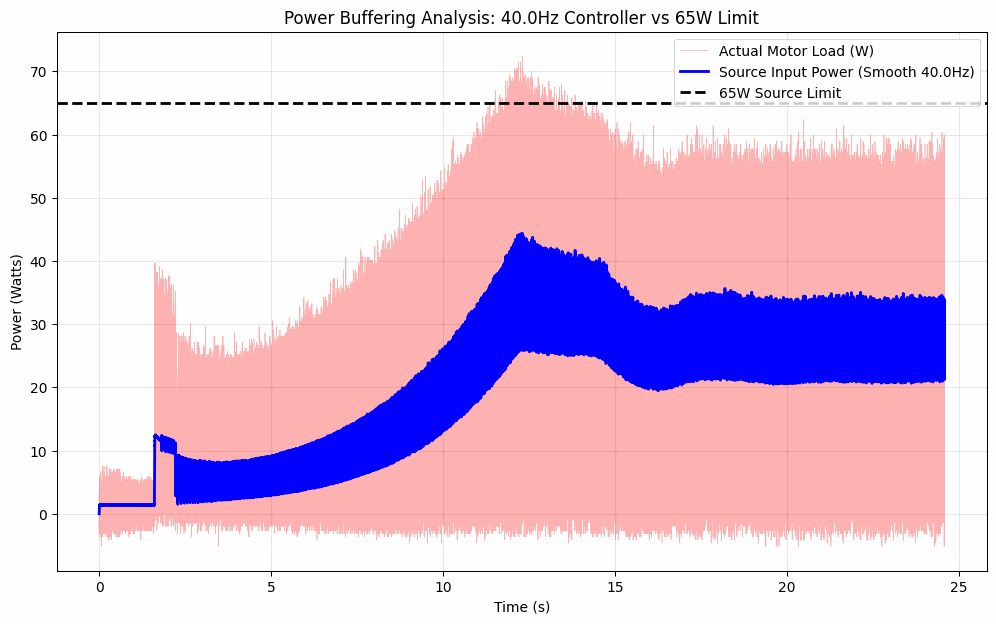

In [3]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy import signal
from scipy.interpolate import interp1d

"""
# --- 1. Load and Clean Data ---
df = pd.read_csv(r'../measurements/Scope_P14Pro_Startup_Current_1r57_shunt.csv', header=None)

# Extract raw columns
raw_t = pd.to_numeric(df[3][1:], errors='coerce')
raw_v = pd.to_numeric(df[4][1:], errors='coerce')

# Drop NaNs
mask = raw_t.notna() & raw_v.notna()
t_raw = raw_t[mask].values
v_raw = raw_v[mask].values
"""
df = pd.read_parquet('../measurements/motor_startup.parquet')
t_raw = df['Time']
v_raw = df['Voltage']
# Shift time so the simulation starts at 0
t_raw = t_raw - t_raw.min()

# Now create your uniform grid
t_uniform = np.linspace(t_raw.min(), t_raw.max(), len(t_raw))
# Convert to Current (Using positive shunt and probe attenuation)
r_shunt = 1.57 
probe_atten = 1
i_load_raw = (v_raw * probe_atten) / r_shunt * 8 # 8 fans in parallel

# --- 2. Fix Non-Equal Spacing (Resampling) ---
# Create a perfectly uniform time grid from the start to end of your data
t_uniform = np.linspace(t_raw.min(), t_raw.max(), len(t_raw))

# Interpolate the raw current onto the uniform grid
f_interp = interp1d(t_raw, i_load_raw, kind='linear', fill_value="extrapolate")
i_load = f_interp(t_uniform)

# --- 3. Define the System (40 Hz Bandwidth) ---
f_bw = 40.0
w_bw = 2 * np.pi * f_bw
# The response of the input source to a load change
sys_input_response = signal.TransferFunction([w_bw], [1, w_bw])

# --- 4. Simulate the Input Power ---
p_load = i_load * 12.0 # Power at the 12V rail
# Use the uniform time vector 't_uniform'
t_sim, p_input, _ = signal.lsim(sys_input_response, U=p_load, T=t_uniform)

# --- 5. Visualize the Result ---
plt.figure(figsize=(12, 7))
plt.plot(t_uniform, p_load, label='Actual Motor Load (W)', alpha=0.3, color='red', linewidth=0.5)
plt.plot(t_sim, p_input, label=f'Source Input Power (Smooth {f_bw}Hz)', linewidth=2, color='blue')
plt.axhline(65, color='black', linestyle='--', label='65W Source Limit', linewidth=2)

plt.title(f'Power Buffering Analysis: {f_bw}Hz Controller vs 65W Limit')
plt.ylabel('Power (Watts)')
plt.xlabel('Time (s)')
plt.grid(True, which='both', alpha=0.3)
plt.legend(loc='upper right')

# Optional: Zoom into the middle of the ramp to see the "fuzz" vs the "smooth" line
#plt.xlim([12.15, 12.2]) 

plt.show()

## Output-voltage response model to the measured load

Total C_out ESR: 36.68 mOhm


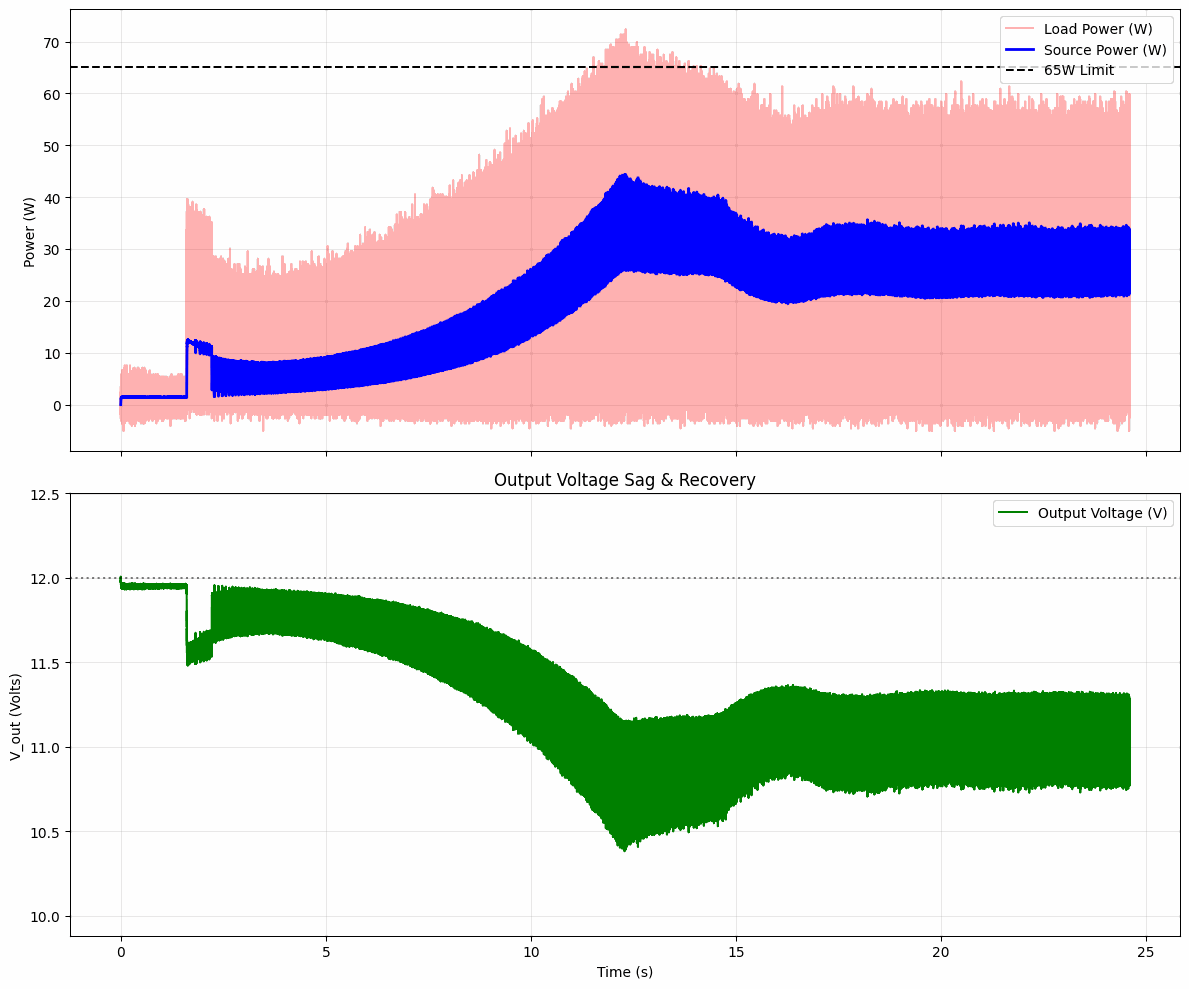

In [4]:
# --- Continuing from the previous script ---
w_bw = 2 * np.pi * 40   # ~40 Hz effective loop bandwidth (see 07_stability notebook)

# ESR Calculation from your provided formula
c_out = 9.4e-3
df_cap = 0.16 + 0.02 * 5
f_df = 120
r_esr = df_cap / (2 * np.pi * f_df * c_out)
print(f"Total C_out ESR: {r_esr*1000:.2f} mOhm")

# --- 1. Define Output Voltage Response ---
# The output voltage deviation (V_out - 12V) is driven by i_load
# through the Output Impedance of the closed-loop system.
# Simplified Z_out(s) = (1/sC_out + R_esr) || (Controller Response)

# For a simplified view, we look at the deviation:
# dV = (I_load / C_out) integrated - (Controller correction) + (I_load * R_esr)

# Define the controller's inability to reject load at high freq
# At high freq, the cap handles it; at low freq, the controller fixes it.
num_z = [r_esr * c_out, 1]
den_z = [c_out, w_bw * c_out] # w_bw from the 40Hz calculation
sys_v_response = signal.TransferFunction(num_z, den_z)

# --- 2. Simulate Voltage Deviation ---
# We simulate how i_load (U) creates a voltage drop (dV)
t_v, v_deviation, _ = signal.lsim(sys_v_response, U=i_load, T=t_uniform)

# Final V_out is nominal 12V minus the deviation
v_final = 12.0 - v_deviation

# --- 3. Plotting Results ---
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(12, 10), sharex=True)

# Top Plot: Current & Power (Source vs Load)
ax1.plot(t_uniform, i_load * 12.0, label='Load Power (W)', alpha=0.3, color='red')
ax1.plot(t_sim, p_input, label='Source Power (W)', color='blue', linewidth=2)
ax1.axhline(65, color='black', linestyle='--', label='65W Limit')
ax1.set_ylabel('Power (W)')
ax1.legend(loc='upper right')
ax1.grid(True, alpha=0.3)

# Bottom Plot: Output Voltage
ax2.plot(t_uniform, v_final, color='green', label='Output Voltage (V)')
ax2.axhline(12, color='black', linestyle=':', alpha=0.5)
ax2.set_ylabel('V_out (Volts)')
ax2.set_xlabel('Time (s)')
ax2.set_title('Output Voltage Sag & Recovery')
ax2.grid(True, alpha=0.3)
ax2.legend()

# Set Y-axis to see the sag clearly (e.g., 8V to 13V)
ax2.set_ylim([v_final.min() - 0.5, 12.5])

plt.tight_layout()
plt.show()

## Appendix: rebuild the parquet cache from raw slices

In [5]:
# Rebuild motor_startup.parquet from the raw scope slices (slow; only when the
# raw data changes). The parquet in measurements/ is the cached result.
REBUILD_PARQUET = False
if REBUILD_PARQUET:
    import pandas as pd
    import glob
    import os
    import numpy as np

    path = r'../measurements/slices'
    all_files = sorted(glob.glob(os.path.join(path, "*.csv")))

    li = []

    for filename in all_files:
        df = pd.read_csv(filename, header=None)
    
        # Extract Trigger Time Offset
        try:
            # Micsig metadata: Row 4, Col 2 is 'Trigger Time'
            trigger_time_str = str(df.iloc[4, 1]).replace(' s', '')
            offset = float(trigger_time_str)
        except Exception as e:
            print(f"Warning: Could not parse offset for {filename}: {e}")
            offset = 0.0

        # Clean data: Column 3 is Time, Column 4 is Voltage
        df_clean = df[pd.to_numeric(df[3], errors='coerce').notnull()].copy()
    
        # Apply time offset and flip the negative voltage to positive
        df_clean['Time'] = pd.to_numeric(df_clean[3]) + offset
        df_clean['Voltage'] = pd.to_numeric(df_clean[4]) * -1.0 # Flip sign here
    
        li.append(df_clean[['Time', 'Voltage']])

    # 2. Combine and Fix Overlaps
    df_total = pd.concat(li, axis=0, ignore_index=True)

    # SORT is essential because of the Trigger Time offsets
    df_total = df_total.sort_values('Time').reset_index(drop=True)

    # 3. Handle Overlaps
    # Since subsampling makes timestamps slightly different, we round time 
    # to a reasonable resolution (e.g., 1 microsecond) and average duplicates
    df_total['Time'] = df_total['Time'].round(6) 
    df_final = df_total.groupby('Time').mean().reset_index()

    # 4. Save
    df_final.to_parquet('../measurements/motor_startup.parquet')
    print(f"Stitching complete. Total points: {len(df_final)}")
    # 3. Fix the "Jump" (If the scope reset time to 0 for each slice)
    # We calculate the time difference and shift each slice to follow the previous one
    # This only works if your slices don't overlap or have gaps
    # (Optional: If Micsig saved absolute time, you don't even need this)
    # Save to the main folder
    #df_total.to_csv('cleaned_motor_startup.csv', index=False)
    #df_total.to_pickle('motor_startup.pkl')
    # You might need to install it first: %pip install pyarrow
    # df_total.to_parquet('../measurements/motor_startup.parquet')